In [1]:
import numpy as np
from gpcam import GPOptimizer

import random

import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import os

from sklearn.neighbors import NearestNeighbors

from scipy.spatial.distance import cdist

import time


import warnings
# Add this at the top of your code or before running experiments
warnings.filterwarnings("ignore", message="No noise function or measurement noise provided.*")

# Using Data Extracted from the Firedrake environment

In [ ]:
# Load the saved data
data = np.load('dragon_complete_dataset_from_firedrake.npz') # This can be found with the Riemannan kernel code in the Github repository.

# Extract all the data
vertices = data['vertices']                      # All mesh vertices (N, 3)
ground_truth = data['ground_truth']              # Ground truth values (N,)

del data 

# Running One GP model training

In [ ]:
# Loading the subset geodesic distance, first 50k points
matrix_size = 100179
geodesic_matrix = np.memmap('dragon_geodesic_matrix_100179_new.npy', # This should be computed before running the code.
                            dtype=np.float32,
                            mode='r',
                            shape=(matrix_size, matrix_size))


# Method 1: Direct conversion (simplest)
all_geodesic_distances = np.array(geodesic_matrix)

del geodesic_matrix


In [7]:
# Step 1: First sample the subset of points
np.random.seed(2355)

# Step 3: Now split the subset into train and test
n_train = 1000
n_test = 5000

# Sample ALL indices at once, then split
indices_all = np.random.choice(len(vertices), size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
x_train = vertices[indices_train,:]
y_train = ground_truth[indices_train]

x_test = vertices[indices_test,:]
y_test = ground_truth[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

Training points: 1000
Test points: 5000


In [ ]:
# Step 2 (Fixed): Define the basic GP components

def matern_kernel_diff1(distance, length):
    """
    Function for the Matern kernel, order of differentiability = 1.
    kernel = (1.0 + ((np.sqrt(3.0) * distance) / (length))) * np.exp(
        -(np.sqrt(3.0) * distance) / length

    Parameters
    ----------
    distance : scalar or np.ndarray
        Distance between a set of points.
    length : scalar
        The length scale hyperparameters.

    Return
    ------
    Kernel output : same as distance parameter.
    """

    kernel = (1.0 + ((np.sqrt(3.0) * distance) / length)) * np.exp(
        -(np.sqrt(3.0) * distance) / length
    )
    return kernel

    
def find_indices_by_lookup_efficient(target_points, all_points, tolerance=1e-10):     
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(all_points)
    distances, indices = nbrs.kneighbors(target_points)
    return indices.flatten()

def bump_k(x1, x2, hps):
    x1_indices = find_indices_by_lookup_efficient(x1, vertices)
    x2_indices = find_indices_by_lookup_efficient(x2, vertices)
    indices_train_comp = find_indices_by_lookup_efficient(x_train, vertices)  # Take it out of the kernel function to make things run faster
    
    # Extract geodesic distances
    # d1: distances from x1 points to training points
    # We want shape: (len(x1), n_train) - each row is one x1 point's distances to all training points
    d1 = all_geodesic_distances[np.ix_(x1_indices, indices_train_comp)]  # Shape: (len(x1), n_train)
    d2 = all_geodesic_distances[np.ix_(x2_indices, indices_train_comp)]  # Shape: (len(x2), n_train)
    
    # Apply bump to create embedding
    # phi_x1[i, :] = embedding of x1[i] based on distances to all training points
    phi_x1 = d1 #  bump(d1, hps[1], beta=1, ampl=1.0)  # Shape: (len(x1), n_train)
    phi_x2 = d2 # bump(d2, hps[1], beta=1, ampl=1.0)  # Shape: (len(x2), n_train)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')  # Shape: (len(x1), len(x2))
    
    #return hps[0] * np.exp(-D_mat**2 / hps[2])
    return hps[0] * matern_kernel_diff1(D_mat, hps[1]) # [2])


def my_noise(x, hps):
    s = np.ones(len(x)) * 1e-5  # hps[3]
    return np.diag(s)

def my_mean(x, hps):
    m = np.ones(len(x)) * 0 # hps[4]
    return m

In [22]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

# 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
y_var = np.var(y_train)

# 2. Bump radius (hps[1]): [min distance, maximum distance]
train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
non_zero_dists = train_geodesic[train_geodesic > 0]


# Define hyperparameter bounds
bounds = np.empty((2, 2))
bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
# bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
bounds[1] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings


# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)

trained_hps = np.array([20.94945291,  0.11843309, 44.54541338])

print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)

print(f"Initial log likelihood: {initial_log_likelihood:.6f}")

# Step 5: Train the GP model
my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='mcmc', max_iter=5000)

# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")

# Final hyperparameters:   [8.27802483e+01 7.58312895e-01 4.99824805e+02 1.81358351e-02 1.07441620e-01]  # Test RMSE: 0.42


Initial hyperparameters: [10.49286108 50.005     ]
Initial log likelihood: -141293.708053
Final hyperparameters:   [4.64217819 3.25956465]
Final log likelihood:    1822.01


RMSE: 0.0004943456862741125


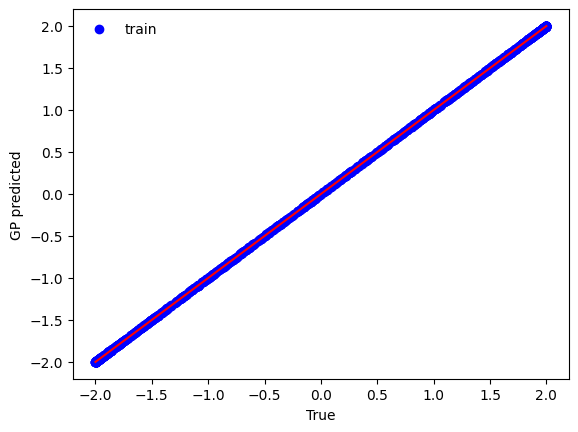

In [25]:
f_train = my_gpo.posterior_mean(x_train)["m(x)"]

my_line = np.linspace(np.min(y_train),np.max(y_train),10)

print('RMSE:', my_gpo.rmse(x_train,y_train)) # *100/np.mean(y_train),'%')

plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

RMSE: 0.026552374253151573


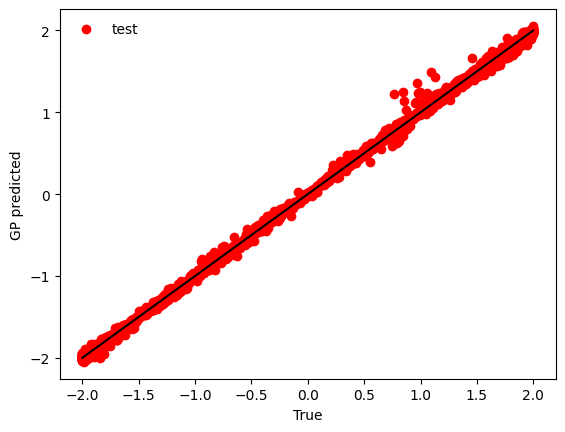

In [26]:
f = my_gpo.posterior_mean(x_test)["m(x)"]

print('RMSE:', my_gpo.rmse(x_test,y_test)) # *100/np.mean(y_test),'%')

my_line = np.linspace(np.min(y_test),np.max(y_train),10)

plt.scatter(y_test,f,color="red",label = 'test')
#plt.scatter(y_train,f_train,color="blue",label = 'train')
plt.plot(my_line,my_line,c="black")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

In [ ]:
x_test = vertices# [indices_test,:]
f = my_gpo.posterior_mean(x_test)["m(x)"]

# Making several trials with different training size

In [7]:
import numpy as np
import random
import json
from tqdm import tqdm


In [8]:
# def generate_training_configurations():
#     # Configuration
#     training_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 
#                      550, 600, 650, 700, 750, 800, 850, 900, 950, 1000]
#     n_trials = 100
#     total_data_points = 100179
    
#     # Generate 100 random seeds
#     np.random.seed(42)
#     random_seeds = np.random.randint(1, 100000, size=n_trials)
    
#     # Generate single test set (NEW LINE)
#     np.random.seed(9999)
#     test_indices = np.random.choice(total_data_points, size=5000, replace=False).tolist()
    
#     # Structure to store all configurations
#     training_configs = {
#         "test_indices": test_indices,  # Add test indices to JSON
#         "training_configurations": {}
#     }
    
#     print(f"Generating configurations for {len(training_sizes)} training sizes...")
#     print(f"Each size will have {n_trials} trials")
    
#     for train_size in tqdm(training_sizes, desc="Training sizes"):
#         train_size_configs = []
        
#         for trial_idx in tqdm(range(n_trials), desc=f"Size {train_size}", leave=False):
#             seed = int(random_seeds[trial_idx])
            
#             # Set seed and generate indices
#             np.random.seed(seed)
#             random.seed(seed)
            
#             # Generate training indices (same as before - no overlap checking)
#             indices_train = random.sample(range(total_data_points), train_size)
            
#             # Store configuration for this trial
#             trial_config = {
#                 "seed": seed,
#                 "indices_train": indices_train
#             }
            
#             train_size_configs.append(trial_config)
        
#         # Store all trials for this training size
#         training_configs["training_configurations"][str(train_size)] = train_size_configs
    
#     return training_configs

# # Generate the configurations
# print("Generating training configurations...")
# training_configs = generate_training_configurations()

# # Save to JSON file
# with open('dragon_example_training_configurations.json', 'w') as f:
#     json.dump(training_configs, f, indent=2)

# print(f"✅ Saved training configurations to 'training_configurations.json'")
# print(f"📊 Test indices: {len(training_configs['test_indices'])}")
# print(f"📊 Training sizes: {len(training_configs['training_configurations'])}")
# print(f"🎯 Total trials: {sum(len(trials) for trials in training_configs['training_configurations'].values())}")

In [ ]:
from scipy.stats import norm

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, vertices, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = vertices[test_indices]
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, vertices, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = vertices[indices_train]
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed, indices_train

def get_hps_bounds(y_train,indices_train):

    # 1. Signal variance (hps[0]): [0.01 * y_var, 10 * y_var]
    y_var = np.var(y_train)
    
    # 2. Bump radius (hps[1]): [min distance, maximum distance]
    train_geodesic = all_geodesic_distances[np.ix_(indices_train, indices_train)]
    non_zero_dists = train_geodesic[train_geodesic > 0]
    
    # Define hyperparameter bounds
    bounds = np.empty((2, 2))
    bounds[0] = np.array([0.01 * y_var, 10 * y_var])                             # sigma_f: signal variance      
    # bounds[1] = np.array([np.min(non_zero_dists), np.max(non_zero_dists)])       # length_scale: bump radius
    bounds[1] = np.array([0.01, 100])                                            # length_scale for RBF on embeddings
    
    return bounds

def train_gp_model(x_train, y_train, bounds):
    """Train GP model with your existing setup"""
    
    # Initial hyperparameters (middle of bounds)
    init_hps = np.mean(bounds, axis=1)
    
    # Initialize GPOptimizer
    my_gpo = GPOptimizer(x_train, y_train,
                         init_hyperparameters=init_hps,
                         kernel_function=bump_k,
                         prior_mean_function=my_mean, 
                         noise_function=my_noise)
    
    # Train the GP model
    my_gpo.train(hyperparameter_bounds=bounds, 
                 init_hyperparameters=init_hps, 
                 method='mcmc', 
                 max_iter=4000)
    
    return my_gpo

def picp(gp_model_object, x_test, y_true, interval=0.95):
        mu = gp_model_object.posterior_mean(x_test)["m(x)"]
        sigma = np.sqrt(gp_model_object.posterior_covariance(x_test, add_noise=True)["v(x)"])

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp
   

def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = 'dragon_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = 'dragon_example_gp_experiment_results_Matern_RegularEmbedding.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, vertices, ground_truth)
    #print(f"Test data shape: {x_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    #print(f"Training sizes: {training_sizes}")
    #print(f"Starting experiments...")
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in tqdm(range(30), desc=f"Size {train_size}"):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed, indices_train = get_training_data(configs, train_size, trial_idx, vertices, ground_truth)


                ##################
                # Make x_train global so kernel functions can access it
                globals()['x_train'] = x_train  # ← Add this line
                globals()['y_train'] = y_train
                globals()['indices_train'] = indices_train  # if bump_k needs this too
                ##################
                
                # Identify the hps bounds
                bounds = get_hps_bounds(y_train,indices_train)

                # Train GP model
                my_gpo = train_gp_model(x_train, y_train, bounds)
                
                # Calculate training RMSE
                train_rmse = my_gpo.rmse(x_train, y_train)
                
                # Calculate testing RMSE
                test_rmse = my_gpo.rmse(x_test, y_test)

                # Compute CRPS
                crps_test = my_gpo.crps(x_test, y_test)

                # Compute picp
                picp_test = picp(my_gpo, x_test, y_test)
                
                # Get final hyperparameters and log likelihood
                final_hps = my_gpo.get_hyperparameters()
                final_ll = my_gpo.log_likelihood(final_hps)
                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'test_crps mean': float(crps_test[0]),
                    'test_crps std': float(crps_test[1]),
                    'test_picp': float(picp_test),
                    'final_log_likelihood': float(final_ll),
                    'final_hyperparameters': final_hps.tolist(),
                    'n_training_points': len(x_train),
                }
                
                all_results.append(result)
                
                # Save after each trial ✅
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} ✅ Saved")
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP experiments...")
print("="*60)

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

🚀 Starting GP experiments...
Loading configurations...
🆕 Creating new results file

=== Training Size: 50 ===


Size 50:   3%|▎         | 1/30 [01:18<38:04, 78.79s/it]

  Trial 0: Train RMSE=0.0000, Test RMSE=0.9864 ✅ Saved


Size 50:   7%|▋         | 2/30 [02:37<36:47, 78.84s/it]

  Trial 1: Train RMSE=0.0000, Test RMSE=0.2828 ✅ Saved


...

  Trial 1: Train RMSE=0.0006, Test RMSE=0.0334 ✅ Saved


Size 900:  10%|█         | 3/30 [11:08<1:39:37, 221.38s/it]

  Trial 2: Train RMSE=0.0005, Test RMSE=0.0233 ✅ Saved


Size 900:  67%|██████▋   | 20/30 [1:26:02<43:01, 258.13s/it]  


KeyboardInterrupt: 

In [4]:
# # delete the cases with errors:

# import json

# # Load the JSON file
# with open('dragon_example_gp_experiment_results.json', 'r') as f:
#     data = json.load(f)

# # Keep only entries 0-379 (delete 380 onwards)
# data_trimmed = data[:380]

# # Save back to the same file
# with open('dragon_example_gp_experiment_results.json', 'w') as f:
#     json.dump(data_trimmed, f, indent=2)

# print(f"Original entries: {len(data)}")
# print(f"Trimmed entries: {len(data_trimmed)}")
# print(f"Deleted: {len(data) - len(data_trimmed)} entries")


## Analyze Results

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def load_and_process_results(filename):
    """Load results and organize by training size"""
    with open(filename, 'r') as f:
        results = json.load(f)
    
    # Organize results by training size
    organized_results = defaultdict(lambda: {'train_rmse': [], 'test_rmse': []})
    
    for result in results:
        # Skip failed trials
        if result.get('status') == 'failed' or 'error' in result:
            continue
            
        train_size = result['training_size']
        train_rmse = result['train_rmse']
        test_rmse = result['test_rmse']
        
        organized_results[train_size]['train_rmse'].append(train_rmse)
        organized_results[train_size]['test_rmse'].append(test_rmse)
    
    return organized_results

def calculate_stats(organized_results, remove_outliers=True, method='iqr'):
    """Calculate mean and standard error for each training size with optional outlier removal"""
    stats = {}
    
    for train_size, rmse_data in organized_results.items():
        train_rmses = np.array(rmse_data['train_rmse'])
        test_rmses = np.array(rmse_data['test_rmse'])
        
        if remove_outliers:
            # Filter outliers from test_rmses
            if method == 'iqr':
                # IQR method
                q1 = np.percentile(test_rmses, 25)
                q3 = np.percentile(test_rmses, 75)
                iqr = q3 - q1
                lower_bound = q1 - 1.5 * iqr
                upper_bound = q3 + 1.5 * iqr
                mask = (test_rmses >= lower_bound) & (test_rmses <= upper_bound)
            
            elif method == 'zscore':
                # Z-score method (typically exclude values > 3 standard deviations)
                z_scores = np.abs((test_rmses - np.mean(test_rmses)) / np.std(test_rmses))
                mask = z_scores < 3
            
            elif method == 'percentile':
                # Remove top and bottom percentiles
                lower = np.percentile(test_rmses, 5)
                upper = np.percentile(test_rmses, 95)
                mask = (test_rmses >= lower) & (test_rmses <= upper)
            
            # Apply mask to both train and test
            train_rmses = train_rmses[mask]
            test_rmses = test_rmses[mask]
        
        stats[train_size] = {
            'train_mean': np.mean(train_rmses),
            'train_sem': np.std(train_rmses) / np.sqrt(len(train_rmses)),
            'test_mean': np.mean(test_rmses),
            'test_sem': np.std(test_rmses) / np.sqrt(len(test_rmses)),
            'n_trials': len(train_rmses)
        }
    
    return stats

# Load your main results
results_file1 = '/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_example_manifold_matern_gp_experiment_results.json'
results1 = load_and_process_results(results_file1)
stats1 = calculate_stats(results1)

# Load comparison results (replace with your second file)
results_file2 = '/pscratch/sd/m/malghal/Flexible_kernels/dragon_example_gp_experiment_results.json'  # Replace with actual filename
results2 = load_and_process_results(results_file2)
stats2 = calculate_stats(results2)

# Load comparison results (replace with your second file)
results_file3 = '/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_example_manifold_matern_gp_experiment_results_100EigenPairs.json'  # Replace with actual filename
results3 = load_and_process_results(results_file3)
stats3 = calculate_stats(results3)

# Load comparison results (replace with your second file)
results_file4 = '/pscratch/sd/m/malghal/Riemannian-Gaussian-Processes/dragon_example_manifold_matern_gp_experiment_results_1000EigenPairs.json'  # Replace with actual filename
results4 = load_and_process_results(results_file4)
stats4 = calculate_stats(results4)


print("📊 Results Summary:")
print("=" * 50)
print("Method 1 (Manifold 500):")
# for train_size in sorted(stats1.keys()):
#     s = stats1[train_size]
#     print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")
print ("Done")

print("\nMethod 2 (Comparison):")
# for train_size in sorted(stats2.keys()):
#     s = stats2[train_size]
#     print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")
print ("Done")

print("\nMethod 3 (Manifold 100):")
# for train_size in sorted(stats3.keys()):
#     s = stats3[train_size]
#     print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")
print ("Done")

print("\nMethod 4 (Manifold 1000):")
for train_size in sorted(stats4.keys()):
    s = stats4[train_size]
    print(f"Size {train_size:3d}: Test RMSE = {s['test_mean']:.4f} ± {s['test_sem']:.4f} ({s['n_trials']} trials)")


📊 Results Summary:
Method 1 (Manifold 500):
Done

Method 2 (Comparison):
Done

Method 3 (Manifold 100):
Done

Method 4 (Manifold 1000):
Size  50: Test RMSE = 0.4919 ± 0.0122 (29 trials)
Size 100: Test RMSE = 0.2831 ± 0.0063 (30 trials)
Size 150: Test RMSE = 0.2134 ± 0.0050 (29 trials)
Size 200: Test RMSE = 0.1691 ± 0.0036 (29 trials)
Size 250: Test RMSE = 0.1460 ± 0.0032 (29 trials)
Size 300: Test RMSE = 0.1274 ± 0.0021 (29 trials)
Size 350: Test RMSE = 0.1128 ± 0.0017 (27 trials)
Size 400: Test RMSE = 0.1082 ± 0.0022 (29 trials)
Size 450: Test RMSE = 0.1040 ± 0.0028 (29 trials)
Size 500: Test RMSE = 0.1025 ± 0.0030 (27 trials)
Size 550: Test RMSE = 0.1084 ± 0.0045 (28 trials)
Size 600: Test RMSE = 0.1120 ± 0.0044 (26 trials)
Size 650: Test RMSE = 0.1355 ± 0.0078 (27 trials)
Size 700: Test RMSE = 0.1734 ± 0.0121 (28 trials)
Size 750: Test RMSE = 0.2450 ± 0.0209 (28 trials)
Size 800: Test RMSE = 0.4061 ± 0.0604 (27 trials)
Size 850: Test RMSE = 0.5390 ± 0.0769 (25 trials)
Size 900: Test

In [2]:
del stats1[500]
del stats1[550]
del stats1[600]

del stats3[100]
del stats3[150]

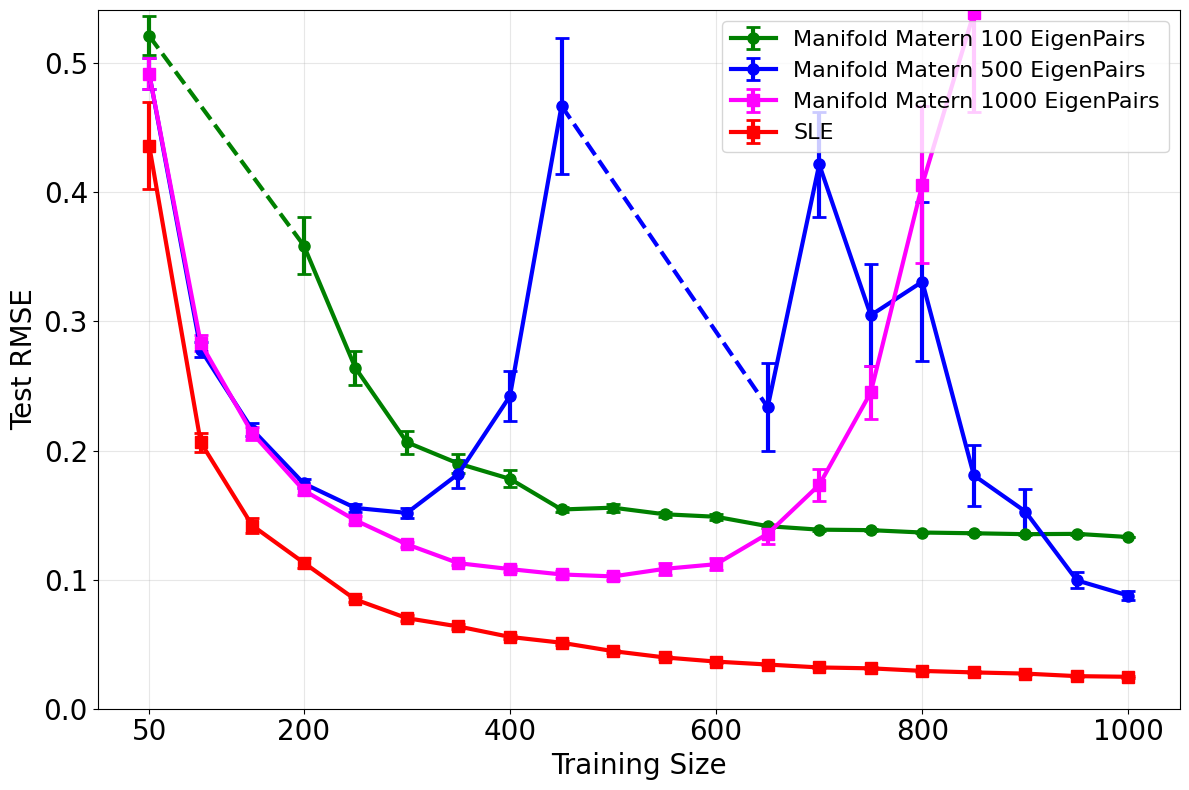

In [4]:
rmse_of_interest = 'test_mean'
sem_of_interest = 'test_sem'

# Create linear scale plot
plt.figure(figsize=(12, 8))

# Extract data for both methods
train_sizes1 = sorted(stats1.keys())
test_means1 = [stats1[size][rmse_of_interest] for size in train_sizes1]
test_sems1 = [stats1[size][sem_of_interest] for size in train_sizes1]

train_sizes2 = sorted(stats2.keys())
test_means2 = [stats2[size][rmse_of_interest] for size in train_sizes2]
test_sems2 = [stats2[size][sem_of_interest] for size in train_sizes2]

train_sizes3 = sorted(stats3.keys())
test_means3 = [stats3[size][rmse_of_interest] for size in train_sizes3]
test_sems3 = [stats3[size][sem_of_interest] for size in train_sizes3]

train_sizes4 = sorted(stats4.keys())
test_means4 = [stats4[size][rmse_of_interest] for size in train_sizes4]
test_sems4 = [stats4[size][sem_of_interest] for size in train_sizes4]

########################################################################################

# Eigen pairs 100
# Plot Manifold Matern 100 eigen pairs with dashed line between 50-200
idx_50 = 0  # First point
idx_200 = train_sizes3.index(200) if 200 in train_sizes3 else None

# Gap (dashed, no error bars)
plt.plot([50, train_sizes3[idx_200]], 
         [test_means3[0], test_means3[idx_200]], 
         linestyle='--', linewidth=3, color='green')

# After gap (solid)
plt.errorbar(train_sizes3[idx_200:], test_means3[idx_200:], yerr=test_sems3[idx_200:], 
            marker='o', linewidth=3, capsize=5, capthick=2,
            label='Manifold Matern 100 EigenPairs', color='green', markersize=8)

# Plot first point for 100 eigenpairs
plt.errorbar([50], [test_means3[0]], yerr=[test_sems3[0]], 
            marker='o', linewidth=3, capsize=5, capthick=2,
            color='green', markersize=8)

############################################

# Eigen pairs 500
# Plot Manifold Matern 500 eigen pairs with dashed line between 450-650
idx_450 = train_sizes1.index(450) if 450 in train_sizes1 else None
idx_650 = train_sizes1.index(650) if 650 in train_sizes1 else None

# Before gap (solid)
plt.errorbar(train_sizes1[:idx_450+1], test_means1[:idx_450+1], yerr=test_sems1[:idx_450+1], 
            marker='o', linewidth=3, capsize=5, capthick=2,
            label='Manifold Matern 500 EigenPairs', color='blue', markersize=8)

# Gap (dashed, no error bars)
plt.plot([train_sizes1[idx_450], train_sizes1[idx_650]], 
         [test_means1[idx_450], test_means1[idx_650]], 
         linestyle='--', linewidth=3, color='blue')

# After gap (solid)
plt.errorbar(train_sizes1[idx_650:], test_means1[idx_650:], yerr=test_sems1[idx_650:], 
            marker='o', linewidth=3, capsize=5, capthick=2,
            color='blue', markersize=8)

##########################################

# Eigen pairs 1000
plt.errorbar(train_sizes4, test_means4, yerr=test_sems4,
            marker='s', linewidth=3, capsize=5, capthick=2,
            label='Manifold Matern 1000 EigenPairs', color='magenta', markersize=8)

############################################
# Flexible Kernel (no gaps)
plt.errorbar(train_sizes2, test_means2, yerr=test_sems2,
            marker='s', linewidth=3, capsize=5, capthick=2,
            label='SLE', color='red', markersize=8)

plt.xlabel('Training Size', fontsize=20)
plt.ylabel('Test RMSE', fontsize=20)
plt.legend(fontsize=16, frameon=True)
plt.grid(True, alpha=0.3)

plt.ylim(0, max(test_means1) * 1.1)
plt.xlim(0,1050)
plt.xticks([50,200,400,600,800,1000])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Dragon_Comparison_Results.pdf", bbox_inches='tight')
plt.show()